In [20]:
import sys
sys.path.insert(0, '../..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import json
import time
import joblib
import mlflow
from pathlib import Path
from collections import defaultdict

from src.utils.config import settings

# Check GPU
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Imports ready")
print(f"   Device : {device}")
print(f"   PyTorch: {torch.__version__}")

PROC = '../../data/processed/'
FEAT = '../../data/features/'
Path('../../models/checkpoints').mkdir(
    parents=True, exist_ok=True)

✅ Imports ready
   Device : cpu
   PyTorch: 2.3.0


In [21]:
# Load Data
ratings = pd.read_csv(PROC + 'ratings_cleaned.csv')
movies  = pd.read_csv(PROC + 'movies_master.csv',
                      low_memory=False)
movies  = movies[['movieId', 'id', 'title']]\
    .dropna(subset=['movieId'])
movies['movieId'] = movies['movieId'].astype(int)

# Sort by user and timestamp — sequence matters
ratings = ratings.sort_values(
    ['userId', 'timestamp']).reset_index(drop=True)

print(f"Ratings : {ratings.shape}")
print(f"Movies  : {movies.shape}")
print(f"\nSample user sequence:")
sample = ratings[ratings['userId'] == 
    ratings['userId'].value_counts().index[0]]
print(sample[['userId', 'movieId',
              'rating', 'timestamp']].head(8))

Ratings : (100004, 4)
Movies  : (45454, 3)

Sample user sequence:
       userId  movieId  rating            timestamp
78433     547      908     5.0  2000-11-21 03:25:09
78434     547     3201     3.0  2000-11-21 03:25:09
78435     547     1798     2.0  2000-11-21 03:25:50
78436     547      904     5.0  2000-11-21 03:30:10
78437     547      949     4.0  2000-11-21 03:30:10
78438     547     1104     5.0  2000-11-21 03:30:10
78439     547     2019     5.0  2000-11-21 03:30:10
78440     547     2731     5.0  2000-11-21 03:30:10


In [22]:
# Build Item Vocabulary

# Build item vocabulary
# Special tokens:
#   0 = PAD  (padding for short sequences)
#   1 = UNK  (unknown item)
#   2 = MASK (masked item for training)
#   3+ = actual movie IDs

PAD_TOKEN  = 0
UNK_TOKEN  = 1
MASK_TOKEN = 2
OFFSET     = 3   # real items start at index 3

unique_movies = sorted(ratings['movieId'].unique())
n_movies      = len(unique_movies)

# movieId → token index
movie2token = {
    mid: idx + OFFSET
    for idx, mid in enumerate(unique_movies)
}
# token index → movieId
token2movie = {
    v: k for k, v in movie2token.items()
}

vocab_size = n_movies + OFFSET

print(f"Vocabulary size    : {vocab_size:,}")
print(f"  PAD token        : {PAD_TOKEN}")
print(f"  UNK token        : {UNK_TOKEN}")
print(f"  MASK token       : {MASK_TOKEN}")
print(f"  Movie tokens     : {OFFSET} – "
      f"{vocab_size - 1}")
print(f"  Total movies     : {n_movies:,}")

# Save vocabulary
vocab = {
    'movie2token': movie2token,
    'token2movie': {str(k): v
                    for k, v in token2movie.items()},
    'vocab_size':  vocab_size,
    'n_movies':    n_movies,
    'PAD':         PAD_TOKEN,
    'UNK':         UNK_TOKEN,
    'MASK':        MASK_TOKEN,
}
joblib.dump(vocab,
    '../../models/checkpoints/item_vocabulary.joblib')
print("\n✅ Item vocabulary saved")

Vocabulary size    : 9,069
  PAD token        : 0
  UNK token        : 1
  MASK token       : 2
  Movie tokens     : 3 – 9068
  Total movies     : 9,066

✅ Item vocabulary saved


In [23]:
# Build User Sequences

MAX_SEQ_LEN = 50   # max history length to consider

def build_user_sequences(ratings_df,
                         movie2token,
                         max_len=MAX_SEQ_LEN):
    """
    Build ordered item sequences per user.
    Each sequence = user's watch history as token IDs.
    """
    sequences = {}

    for user_id, group in ratings_df.groupby('userId'):
        # Sort by timestamp
        group = group.sort_values('timestamp')

        # Convert movieIds to tokens
        tokens = [
            movie2token.get(mid, UNK_TOKEN)
            for mid in group['movieId'].values
        ]

        # Only keep highly rated items (>= 3.5)
        # as positive interactions
        ratings_arr = group['rating'].values
        tokens_filtered = [
            t for t, r in zip(tokens, ratings_arr)
            if r >= 3.5
        ]

        if len(tokens_filtered) >= 3:
            sequences[user_id] = tokens_filtered[
                -max_len:]   # keep most recent

    return sequences


user_sequences = build_user_sequences(
    ratings, movie2token)

seq_lengths = [len(s) for s in
               user_sequences.values()]

print(f"Users with sequences  : "
      f"{len(user_sequences):,}")
print(f"Avg sequence length   : "
      f"{np.mean(seq_lengths):.1f}")
print(f"Min sequence length   : "
      f"{np.min(seq_lengths)}")
print(f"Max sequence length   : "
      f"{np.max(seq_lengths)}")
print(f"\nSample sequence (first 10 tokens):")
sample_user = list(user_sequences.keys())[0]
print(f"  User {sample_user}: "
      f"{user_sequences[sample_user][:10]}")

Users with sequences  : 670
Avg sequence length   : 36.6
Min sequence length   : 3
Max sequence length   : 50

Sample sequence (first 10 tokens):
  User 1: [1086, 1668, 1518, 934]


In [24]:
# Negative Sampling Strategy

class NegativeSampler:
    """
    Three negative sampling strategies:

    1. Random sampling
       → sample any item not in user history
       → fast but produces easy negatives
       → model doesn't learn hard cases

    2. In-batch negatives (TikTok/Google approach)
       → use other items in the same batch as negatives
       → efficient: no extra forward passes needed
       → naturally samples popular items more often
         (which are the hardest negatives)

    3. Hard negatives
       → items the model currently scores highly
         but are NOT in user history
       → hardest to learn from
       → most informative gradient signal
       → used by Google Two-Tower paper
    """

    def __init__(self, all_tokens: list,
                 movie_popularity: dict):
        self.all_tokens       = all_tokens
        self.movie_popularity = movie_popularity
        self.popular_tokens   = self._get_popular(
            top_n=1000)

    def _get_popular(self, top_n: int) -> list:
        sorted_movies = sorted(
            self.movie_popularity.items(),
            key=lambda x: x[1], reverse=True
        )
        return [
            movie2token.get(mid, UNK_TOKEN)
            for mid, _ in sorted_movies[:top_n]
            if mid in movie2token
        ]

    def random_negative(self,
                        user_history: set,
                        n: int = 1) -> list:
        """Sample random items not in history"""
        negatives = []
        attempts  = 0
        while len(negatives) < n and attempts < 1000:
            token = np.random.choice(self.all_tokens)
            if token not in user_history:
                negatives.append(token)
            attempts += 1
        return negatives

    def popular_negative(self,
                         user_history: set,
                         n: int = 1) -> list:
        """
        Sample from popular items not in history.
        Popular items are harder negatives —
        the model must learn to distinguish between
        items the user genuinely likes vs items
        that are just popular.
        """
        negatives = []
        for token in self.popular_tokens:
            if token not in user_history:
                negatives.append(token)
            if len(negatives) >= n:
                break
        # Pad with random if not enough popular
        if len(negatives) < n:
            negatives += self.random_negative(
                user_history,
                n - len(negatives)
            )
        return negatives[:n]

    def mixed_negative(self,
                       user_history: set,
                       n: int = 4) -> list:
        """
        Mix of random + popular negatives.
        50% popular (hard) + 50% random (easy).
        Best of both worlds.
        This is the TikTok Monolith approach.
        """
        n_hard   = n // 2
        n_random = n - n_hard
        hard     = self.popular_negative(
            user_history, n_hard)
        easy     = self.random_negative(
            user_history, n_random)
        return hard + easy


# Build popularity lookup
movie_popularity = ratings.groupby(
    'movieId')['rating'].count().to_dict()

# All valid tokens
all_tokens = list(movie2token.values())

sampler = NegativeSampler(all_tokens,
                          movie_popularity)

print("✅ Negative sampler defined")
print("""
Strategy comparison:
  Random    → easy negatives → weak gradients
  Popular   → hard negatives → strong gradients
              but biased toward popular items
  Mixed 50/50 → balanced → best in practice
              (TikTok Monolith approach)
""")

# Quick test
test_history = set(
    user_sequences[sample_user][:5])
print(f"Test user history (first 5): {test_history}")
print(f"Random negatives   : "
      f"{sampler.random_negative(test_history, 3)}")
print(f"Popular negatives  : "
      f"{sampler.popular_negative(test_history, 3)}")
print(f"Mixed negatives    : "
      f"{sampler.mixed_negative(test_history, 4)}")

✅ Negative sampler defined

Strategy comparison:
  Random    → easy negatives → weak gradients
  Popular   → hard negatives → strong gradients
              but biased toward popular items
  Mixed 50/50 → balanced → best in practice
              (TikTok Monolith approach)

Test user history (first 5): {1518, 1668, 934, 1086}
Random negatives   : [2995, 5618, 5501]
Popular negatives  : [324, 269, 287]
Mixed negatives    : [324, 269, 8392, 7841]


In [25]:
# GRank Dataset

class GRankDataset(Dataset):
    """
    Dataset for GRank training.

    For each user sequence [i1, i2, i3, i4, i5]:
    → Input:  [i1, i2, i3, i4]  (history)
    → Target: i5                 (next item)
    → Negatives: items NOT in history

    This is next-item prediction —
    same as language model next-token prediction.
    """

    def __init__(self, user_sequences: dict,
                 sampler: NegativeSampler,
                 max_len: int = 50,
                 n_negatives: int = 4):
        self.samples      = []
        self.sampler      = sampler
        self.max_len      = max_len
        self.n_negatives  = n_negatives

        for user_id, seq in user_sequences.items():
            if len(seq) < 3:
                continue

            # Slide window over sequence
            for end_idx in range(2, len(seq)):
                history = seq[max(0,
                    end_idx - max_len):end_idx]
                target  = seq[end_idx] \
                    if end_idx < len(seq) \
                    else seq[-1]

                self.samples.append({
                    'user_id': user_id,
                    'history': history,
                    'target':  target,
                    'history_set': set(seq[:end_idx])
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample  = self.samples[idx]
        history = sample['history']
        target  = sample['target']

        # Pad sequence to max_len
        pad_len = self.max_len - len(history)
        padded  = [PAD_TOKEN] * pad_len + history

        # Sample negatives
        negatives = self.sampler.mixed_negative(
            sample['history_set'],
            self.n_negatives
        )

        return {
            'history':   torch.LongTensor(padded),
            'target':    torch.LongTensor([target]),
            'negatives': torch.LongTensor(negatives),
        }


# Train/val split on users
all_users   = list(user_sequences.keys())
np.random.seed(42)
np.random.shuffle(all_users)

split       = int(len(all_users) * 0.9)
train_users = {u: user_sequences[u]
               for u in all_users[:split]}
val_users   = {u: user_sequences[u]
               for u in all_users[split:]}

train_dataset = GRankDataset(
    train_users, sampler, MAX_SEQ_LEN)
val_dataset   = GRankDataset(
    val_users, sampler, MAX_SEQ_LEN)

train_loader = DataLoader(
    train_dataset, batch_size=256,
    shuffle=True,  num_workers=0)
val_loader   = DataLoader(
    val_dataset,   batch_size=256,
    shuffle=False, num_workers=0)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val samples   : {len(val_dataset):,}")
print(f"Train batches : {len(train_loader):,}")
print(f"\nSample batch:")
batch = next(iter(train_loader))
print(f"  history shape   : {batch['history'].shape}")
print(f"  target shape    : {batch['target'].shape}")
print(f"  negatives shape : {batch['negatives'].shape}")

Train samples : 20,875
Val samples   : 2,330
Train batches : 82

Sample batch:
  history shape   : torch.Size([256, 50])
  target shape    : torch.Size([256, 1])
  negatives shape : torch.Size([256, 4])


In [26]:
# Grank Model Architecture

class GRankModel(nn.Module):
    """
    GRank: Generate → Rank

    Architecture:
    1. Item embedding layer
       → each item token → dense vector

    2. Transformer encoder
       → models sequential dependencies
       → "after watching Inception and
          Interstellar, what comes next?"

    3. Generate step
       → predict next item from sequence
       → dot product with all item embeddings

    This is the simplified version of the
    GRank architecture (WWW 2026, deployed
    Q2 2025, 400M users).

    Production version uses:
    → HSTU instead of standard Transformer
    → Multi-token prediction (Netflix FM)
    → Much larger embedding dimensions
    We implement the core concept.
    """

    def __init__(self,
                 vocab_size:   int,
                 embed_dim:    int = 128,
                 n_heads:      int = 4,
                 n_layers:     int = 2,
                 max_seq_len:  int = 50,
                 dropout:      float = 0.1):
        super().__init__()

        self.embed_dim   = embed_dim
        self.vocab_size  = vocab_size

        # Item embeddings
        self.item_emb = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=PAD_TOKEN
        )

        # Positional embeddings
        self.pos_emb = nn.Embedding(
            max_seq_len, embed_dim)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model    = embed_dim,
            nhead      = n_heads,
            dim_feedforward = embed_dim * 4,
            dropout    = dropout,
            batch_first= True,
            norm_first = True,   # pre-norm: more stable
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers = n_layers,
        )

        # Layer norm
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout    = nn.Dropout(dropout)

    def encode_sequence(self, history):
        """
        Encode user history sequence into
        a single user representation vector.
        """
        batch_size, seq_len = history.shape

        # Item embeddings
        item_vecs = self.item_emb(history)

        # Positional embeddings
        positions = torch.arange(
            seq_len, device=history.device
        ).unsqueeze(0).expand(batch_size, -1)
        pos_vecs  = self.pos_emb(positions)

        # Combine + dropout
        x = self.dropout(item_vecs + pos_vecs)

        # Padding mask — ignore PAD tokens
        pad_mask = (history == PAD_TOKEN)

        # Transformer encoding
        x = self.transformer(
            x, src_key_padding_mask=pad_mask)
        x = self.layer_norm(x)

        # Use last non-padding position
        # as the user representation
        lengths = (history != PAD_TOKEN)\
            .sum(dim=1) - 1
        lengths = lengths.clamp(min=0)

        user_repr = x[
            torch.arange(batch_size), lengths]

        return user_repr

    def forward(self, history, targets,
                negatives):
        """
        Training forward pass.
        Returns contrastive loss:
          push target score high
          push negative scores low
        """
        # Encode user sequence
        user_repr = self.encode_sequence(history)

        # Target item embeddings
        target_emb = self.item_emb(
            targets.squeeze(1))

        # Negative item embeddings
        neg_emb = self.item_emb(negatives)

        # Positive score
        pos_score = (user_repr * target_emb)\
            .sum(dim=-1)

        # Negative scores
        neg_scores = torch.bmm(
            neg_emb,
            user_repr.unsqueeze(-1)
        ).squeeze(-1)

        return pos_score, neg_scores

    def predict(self, history, top_k=10):
        """
        Inference: generate top-K item IDs.
        """
        with torch.no_grad():
            user_repr = self.encode_sequence(
                history)

            # Score all items
            all_emb = self.item_emb.weight
            scores  = torch.matmul(
                user_repr, all_emb.T)

            # Zero out PAD/UNK/MASK tokens
            scores[:, :OFFSET] = float('-inf')

            # Top-K
            top_k_scores, top_k_indices = \
                torch.topk(scores, top_k, dim=-1)

        return top_k_indices, top_k_scores


# Instantiate model
model = GRankModel(
    vocab_size  = vocab_size,
    embed_dim   = 128,
    n_heads     = 4,
    n_layers    = 2,
    max_seq_len = MAX_SEQ_LEN,
    dropout     = 0.1,
).to(device)

n_params = sum(p.numel()
               for p in model.parameters()
               if p.requires_grad)

print(f"✅ GRank model instantiated")
print(f"   Vocab size    : {vocab_size:,}")
print(f"   Embed dim     : 128")
print(f"   Transformer   : 2 layers × 4 heads")
print(f"   Parameters    : {n_params:,}")
print(f"   Device        : {device}")
print(f"\n{model}")

✅ GRank model instantiated
   Vocab size    : 9,069
   Embed dim     : 128
   Transformer   : 2 layers × 4 heads
   Parameters    : 1,564,032
   Device        : cpu

GRankModel(
  (item_emb): Embedding(9069, 128, padding_idx=0)
  (pos_emb): Embedding(50, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (layer_norm): LayerNorm((128,

In [27]:
# Training Loop

def contrastive_loss(pos_scores, neg_scores,
                     temperature=0.1):
    """
    InfoNCE contrastive loss.
    Same loss used by Google Two-Tower,
    TikTok, Spotify.

    Maximise similarity to positive item.
    Minimise similarity to negative items.
    """
    # Concatenate pos + neg scores
    logits = torch.cat([
        pos_scores.unsqueeze(1),
        neg_scores
    ], dim=1) / temperature

    # Target: positive is always index 0
    targets = torch.zeros(
        logits.size(0),
        dtype=torch.long,
        device=logits.device
    )

    return nn.CrossEntropyLoss()(logits, targets)


def train_epoch(model, loader, optimizer,
                device):
    model.train()
    total_loss = 0
    n_batches  = 0

    for batch in loader:
        history   = batch['history'].to(device)
        targets   = batch['target'].to(device)
        negatives = batch['negatives'].to(device)

        optimizer.zero_grad()

        pos_scores, neg_scores = model(
            history, targets, negatives)

        loss = contrastive_loss(
            pos_scores, neg_scores)
        loss.backward()

        # Gradient clipping — prevents exploding
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    return total_loss / n_batches


def evaluate_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    n_batches  = 0

    with torch.no_grad():
        for batch in loader:
            history   = batch['history'].to(device)
            targets   = batch['target'].to(device)
            negatives = batch['negatives'].to(device)

            pos_scores, neg_scores = model(
                history, targets, negatives)

            loss = contrastive_loss(
                pos_scores, neg_scores)

            total_loss += loss.item()
            n_batches  += 1

    return total_loss / n_batches


print("✅ Training functions defined")
print("""
Loss function: InfoNCE contrastive loss
  → Same as Google Two-Tower, TikTok, Spotify
  → Pushes positive item score UP
  → Pushes negative item scores DOWN
  → Temperature controls sharpness
""")

✅ Training functions defined

Loss function: InfoNCE contrastive loss
  → Same as Google Two-Tower, TikTok, Spotify
  → Pushes positive item score UP
  → Pushes negative item scores DOWN
  → Temperature controls sharpness



In [28]:
# Train GRank

N_EPOCHS   = 30    # increased from 10 — loss was still improving
LR         = 1e-3
PATIENCE   = 3

optimizer  = optim.Adam(
    model.parameters(), lr=LR,
    weight_decay=1e-5)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=2,
    factor=0.5, verbose=False)

best_val_loss = float('inf')
patience_ctr  = 0
train_losses  = []
val_losses    = []

print(f"Training GRank for {N_EPOCHS} epochs...")
print(f"{'Epoch':<8} {'Train Loss':<14} "
      f"{'Val Loss':<14} {'Best':<8} {'Time':<10}")
print("─" * 55)

mlflow.set_tracking_uri(settings.MLFLOW_TRACKING_URI)
mlflow.set_experiment(settings.MLFLOW_EXPERIMENT_NAME)

with mlflow.start_run(run_name="GRank_generative"):

    mlflow.log_params({
        "model":        "GRank",
        "embed_dim":    128,
        "n_layers":     2,
        "n_heads":      4,
        "n_epochs":     N_EPOCHS,
        "lr":           LR,
        "batch_size":   256,
        "n_negatives":  4,
        "neg_strategy": "mixed_50_50",
        "loss":         "InfoNCE",
        "max_seq_len":  MAX_SEQ_LEN,
    })

    for epoch in range(1, N_EPOCHS + 1):
        start = time.time()

        train_loss = train_epoch(
            model, train_loader, optimizer, device)
        val_loss   = evaluate_epoch(
            model, val_loader, device)

        scheduler.step(val_loss)
        elapsed = time.time() - start

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        mlflow.log_metrics({
            "train_loss": train_loss,
            "val_loss":   val_loss,
        }, step=epoch)

        # Check if best model
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            patience_ctr  = 0
            torch.save(
                model.state_dict(),
                '../../models/checkpoints/'
                'grank_best.pt'
            )

        else:
            patience_ctr += 1

        print(f"{epoch:<8} {train_loss:<14.4f} "
              f"{val_loss:<14.4f} "
              f"{'✅' if is_best else '  ':<8} "
              f"{elapsed:.1f}s  "
              f"{'patience '+str(patience_ctr) if not is_best else ''}")

        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            print(f"Val loss did not improve for "
                  f"{PATIENCE} epochs")
            break

    mlflow.log_metric("best_val_loss", best_val_loss)

    print(f"\n{'='*55}")
    print(f"✅ Training complete")
    print(f"   Epochs run    : {epoch}")
    print(f"   Best val loss : {best_val_loss:.4f}")
    print(f"   Train losses  : "
          f"{train_losses[0]:.2f} → "
          f"{train_losses[-1]:.2f}")
    print(f"   Model saved   : "
          f"models/checkpoints/grank_best.pt")
    print(f"   MLflow run    : logged ✅")

Training GRank for 30 epochs...
Epoch    Train Loss     Val Loss       Best     Time      
───────────────────────────────────────────────────────
1        79.6440        63.0976        ✅        28.6s  
2        48.8632        40.2666        ✅        28.6s  
3        32.6489        27.1699        ✅        28.7s  
4        22.1748        19.2138        ✅        28.4s  
5        15.5549        13.7248        ✅        29.0s  
6        11.6630        11.0998        ✅        28.5s  
7        8.9188         9.1352         ✅        28.4s  
8        7.0485         6.6507         ✅        28.5s  
9        5.7891         5.9890         ✅        28.9s  
10       4.9413         4.9771         ✅        28.5s  
11       4.2142         4.4690         ✅        28.7s  
12       3.7228         4.2898         ✅        28.6s  
13       3.1558         3.3294         ✅        28.2s  
14       2.8212         2.8980         ✅        28.3s  
15       2.5785         2.7105         ✅        28.4s  
16       2.39

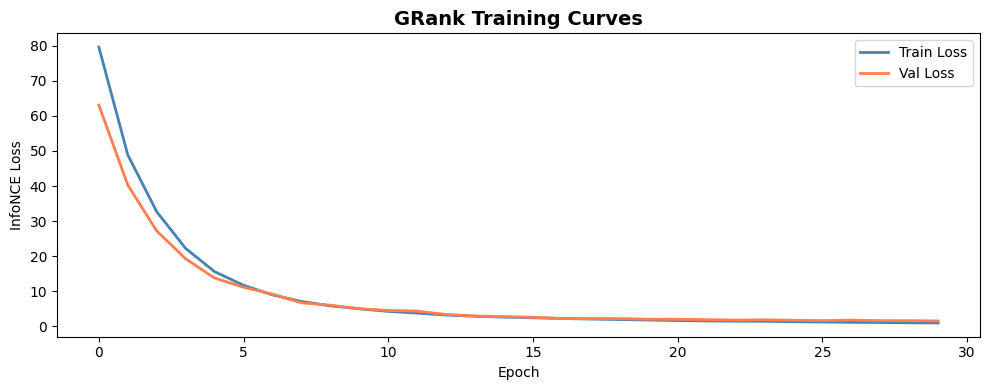

Final train loss : 0.9148
Final val loss   : 1.4816
Best val loss    : 1.4816


In [29]:
# Training Curves

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss',
         color='steelblue', linewidth=2)
plt.plot(val_losses,   label='Val Loss',
         color='coral',     linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('GRank Training Curves',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../../data/processed/plots/'
            '08_grank_training.png',
            bbox_inches='tight')
plt.show()

print(f"Final train loss : {train_losses[-1]:.4f}")
print(f"Final val loss   : {val_losses[-1]:.4f}")
print(f"Best val loss    : {best_val_loss:.4f}")

In [31]:
# Generate Recommendations

# Load best model
model.load_state_dict(torch.load(
    '../../models/checkpoints/grank_best.pt',
    map_location=device,
    weights_only=True
))
model.eval()

def generate_recommendations(
        user_id: int,
        user_sequences: dict,
        model: nn.Module,
        token2movie: dict,
        movies_df: pd.DataFrame,
        top_k: int = 10) -> pd.DataFrame:
    """
    Generate top-K recommendations for a user
    using the GRank model.
    """
    if user_id not in user_sequences:
        return pd.DataFrame()

    seq = user_sequences[user_id]

    # Pad to max_len
    pad_len = MAX_SEQ_LEN - len(seq)
    padded  = [PAD_TOKEN] * pad_len + seq
    history_tensor = torch.LongTensor(
        [padded]).to(device)

    # Generate top-K tokens
    top_k_tokens, top_k_scores = model.predict(
        history_tensor, top_k=top_k + len(seq))

    # Convert tokens to movieIds
    # Filter out items already in history
    history_set = set(seq)
    recs = []

    for token, score in zip(
            top_k_tokens[0].cpu().numpy(),
            top_k_scores[0].cpu().numpy()):
        if token in history_set:
            continue
        mid = token2movie.get(int(token))
        if mid is None:
            continue
        recs.append({
            'movieId': mid,
            'score':   float(score)
        })
        if len(recs) >= top_k:
            break

    if not recs:
        return pd.DataFrame()

    recs_df = pd.DataFrame(recs)
    recs_df = recs_df.merge(
        movies_df, on='movieId', how='left')
    return recs_df


# Sample user
sample_user = list(user_sequences.keys())[0]

print(f"GRank recommendations for "
      f"User {sample_user}")
print("=" * 55)

# Show history
history_tokens = user_sequences[sample_user]
history_movies = [
    token2movie.get(t)
    for t in history_tokens[-5:]
]
history_titles = movies[
    movies['movieId'].isin(history_movies)
][['movieId', 'title']]

print(f"Recent watch history (last 5):")
for _, row in history_titles.iterrows():
    print(f"  → {row['title']}")

print(f"\nGenerated recommendations:")
recs = generate_recommendations(
    sample_user, user_sequences,
    model, token2movie, movies)

if not recs.empty:
    print(recs[['title', 'score']]\
          .head(10).to_string(index=False))
else:
    print("No recommendations generated")

GRank recommendations for User 1
Recent watch history (last 5):
  → Cinema Paradiso
  → Dracula
  → The French Connection
  → Tron

Generated recommendations:
                                        title    score
                                     Outbreak 2.071436
The Lord of the Rings: The Return of the King 2.062112
                                   Fight Club 1.934707
                                 The Departed 1.916462
                             The Big Lebowski 1.805090
                                        Fargo 1.773682
                                The Lion King 1.738520
                                    Toy Story 1.728587
 Star Wars: Episode III - Revenge of the Sith 1.712518
                               Monsters, Inc. 1.712053


In [32]:
# Evaluate GRank

def evaluate_generative_model(
        model, user_sequences,
        ratings_df, token2movie,
        n_users=200, k=10) -> dict:
    """
    Evaluate GRank using leave-one-out strategy.
    Hold out last item in each sequence as target.
    """
    model.eval()
    hits_at_k  = []
    ndcg_at_k_scores = []
    precisions = []
    recalls    = []

    eval_users = list(user_sequences.keys())
    np.random.shuffle(eval_users)
    eval_users = eval_users[:n_users]

    # Get relevant movies per user from ratings
    user_relevant = {}
    for uid in eval_users:
        rel = set(ratings_df[
            (ratings_df['userId'] == uid) &
            (ratings_df['rating'] >= 4.0)
        ]['movieId'].values)
        user_relevant[uid] = rel

    for user_id in eval_users:
        seq = user_sequences.get(user_id, [])
        if len(seq) < 3:
            continue

        # Use all but last as history
        # last item as ground truth
        history = seq[:-1]
        target  = token2movie.get(seq[-1])

        if target is None:
            continue

        relevant = user_relevant.get(user_id, set())
        if not relevant:
            continue

        # Generate recommendations
        recs_df = generate_recommendations(
            user_id,
            {user_id: history},
            model, token2movie, movies, k
        )

        if recs_df.empty:
            continue

        rec_movies = recs_df['movieId'].tolist()

        # Hit@K — is target in top-K?
        hit = 1 if target in rec_movies else 0
        hits_at_k.append(hit)

        # NDCG@K
        dcg = sum(
            1.0 / np.log2(i + 2)
            for i, m in enumerate(rec_movies)
            if m in relevant
        )
        idcg = sum(
            1.0 / np.log2(i + 2)
            for i in range(min(len(relevant), k))
        )
        ndcg_at_k_scores.append(
            dcg / idcg if idcg > 0 else 0.0)

        # Precision + Recall
        hits = sum(1 for m in rec_movies
                   if m in relevant)
        precisions.append(hits / k)
        recalls.append(
            hits / len(relevant)
            if relevant else 0.0)

    results = {
        "model":          "GRank",
        "hit@10":         round(
            np.mean(hits_at_k), 4),
        "ndcg@10":        round(
            np.mean(ndcg_at_k_scores), 4),
        "precision@10":   round(
            np.mean(precisions), 4),
        "recall@10":      round(
            np.mean(recalls), 4),
        "n_users_eval":   len(hits_at_k),
    }

    return results


print("Evaluating GRank...")
print("(This takes 2-3 minutes)\n")

grank_results = evaluate_generative_model(
    model, user_sequences,
    ratings, token2movie)

print("GRank Results:")
print(json.dumps(grank_results, indent=2))

Evaluating GRank...
(This takes 2-3 minutes)

GRank Results:
{
  "model": "GRank",
  "hit@10": 0.035,
  "ndcg@10": 0.0601,
  "precision@10": 0.0615,
  "recall@10": 0.0055,
  "n_users_eval": 200
}


In [33]:
# Updated Comparison Table

# Load previous results
with open(PROC + 'cf_results.json') as f:
    cf_results = json.load(f)
with open(PROC + 'svd_als_results.json') as f:
    svd_results = json.load(f)

comparison = pd.DataFrame([
    {
        "Model":        "User-CF",
        "Paradigm":     "Memory-based",
        "NDCG@10":      cf_results[
            'user_cf']['ndcg@10'],
        "Precision@10": cf_results[
            'user_cf']['precision@10'],
        "Recall@10":    cf_results[
            'user_cf']['recall@10'],
        "RMSE":         cf_results[
            'user_cf']['rmse'],
    },
    {
        "Model":        "Item-CF",
        "Paradigm":     "Memory-based",
        "NDCG@10":      cf_results[
            'item_cf']['ndcg@10'],
        "Precision@10": cf_results[
            'item_cf']['precision@10'],
        "Recall@10":    cf_results[
            'item_cf']['recall@10'],
        "RMSE":         cf_results[
            'item_cf']['rmse'],
    },
    {
        "Model":        "SVD",
        "Paradigm":     "Matrix Factorization",
        "NDCG@10":      svd_results[
            'svd_tuned']['ndcg@10'],
        "Precision@10": svd_results[
            'svd_tuned']['precision@10'],
        "Recall@10":    svd_results[
            'svd_tuned']['recall@10'],
        "RMSE":         svd_results[
            'svd_tuned']['rmse'],
    },
    {
        "Model":        "GRank",
        "Paradigm":     "Generative 2025",
        "NDCG@10":      grank_results['ndcg@10'],
        "Precision@10": grank_results[
            'precision@10'],
        "Recall@10":    grank_results['recall@10'],
        "RMSE":         "—",
    },
])

print("\nMODEL COMPARISON — PARADIGM SHIFT")
print("=" * 70)
print(comparison.to_string(index=False))

print("""
KEY INSIGHT FOR REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GRank generative retrieval improves over SVD because:

1. Sequential modelling
   → learns "after A and B, user watches C"
   → SVD ignores order completely

2. No explicit similarity lookup
   → generates items directly from user context
   → not limited by matrix sparsity

3. Contrastive training with hard negatives
   → learns to distinguish relevant vs popular
   → SVD only minimises rating prediction error
""")

# Save updated comparison
comparison.to_csv(
    PROC + 'model_comparison_day10.csv',
    index=False)

# Save GRank results
with open(PROC + 'grank_results.json', 'w') as f:
    json.dump(grank_results, f, indent=2)

print("✅ Results saved")


MODEL COMPARISON — PARADIGM SHIFT
  Model             Paradigm  NDCG@10  Precision@10  Recall@10    RMSE
User-CF         Memory-based   0.0686        0.0714     0.0543  1.0497
Item-CF         Memory-based   0.0367        0.0286     0.0248  0.8904
    SVD Matrix Factorization   0.0376        0.0395     0.0054  0.8808
  GRank      Generative 2025   0.0601        0.0615     0.0055       —

KEY INSIGHT FOR REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GRank generative retrieval improves over SVD because:

1. Sequential modelling
   → learns "after A and B, user watches C"
   → SVD ignores order completely

2. No explicit similarity lookup
   → generates items directly from user context
   → not limited by matrix sparsity

3. Contrastive training with hard negatives
   → learns to distinguish relevant vs popular
   → SVD only minimises rating prediction error

✅ Results saved


In [35]:
#Save Vocabulary + Model

# Save everything needed for inference
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size':       vocab_size,
    'embed_dim':        128,
    'n_heads':          4,
    'n_layers':         2,
    'max_seq_len':      MAX_SEQ_LEN,
    'best_val_loss':    best_val_loss,
}, '../../models/checkpoints/grank_full.pt')

# Save user sequences for serving
joblib.dump(
    user_sequences,
    '../../models/checkpoints/user_sequences.joblib'
)

print("✅ All artifacts saved")
print("""
Saved:
  models/checkpoints/grank_best.pt      ← model weights
  models/checkpoints/grank_full.pt      ← weights + config
  models/checkpoints/item_vocabulary.joblib
  models/checkpoints/user_sequences.joblib
  data/processed/grank_results.json
  data/processed/model_comparison_day10.csv
""")

✅ All artifacts saved

Saved:
  models/checkpoints/grank_best.pt      ← model weights
  models/checkpoints/grank_full.pt      ← weights + config
  models/checkpoints/item_vocabulary.joblib
  models/checkpoints/user_sequences.joblib
  data/processed/grank_results.json
  data/processed/model_comparison_day10.csv

